<a href="https://colab.research.google.com/github/ngtan369/Randomized-SVD-in-compress-Data/blob/main/svd_compressData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">
  <img src="https://oisp.hcmut.edu.vn/en/wp-content/uploads/2017/10/HCMUT-BachKhoa-Logo-480x487.png" alt="HCMUT Logo" width="150">
  
***Phân tích Randomized SVD (Truncated SVD) và Ứng dụng trong nén dữ liệu****

</div>

In [3]:
print("Hello Linear Algebra Course !!")

Hello Linear Algebra Course !!


# I. Cơ sở lý thuyết của SVD và Compact SVD

### Singular Value Decomposition (SVD)

Phân tích giá trị kỳ dị (SVD) là một kỹ thuật phân tách ma trận mạnh mẽ, tổng quát hóa khái niệm phân tích riêng (eigen-decomposition) cho các ma trận không vuông. Đối với một ma trận thực $A$ kích thước $m \times n$, SVD phân tách $A$ thành ba ma trận:

$$A = U \Sigma V^T$$

Trong đó:
- $U$ là ma trận trực giao $m \times m$ (`U U^T = I`), các cột của $U$ được gọi là **vector kỳ dị trái**.
- $\Sigma$ (Sigma) là ma trận đường chéo $m \times n$ chứa các **giá trị kỳ dị** không âm, theo thứ tự giảm dần trên đường chéo chính: $\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_{\min(m,n)} \ge 0$. Các phần tử ngoài đường chéo bằng 0.
- $V$ là ma trận trực giao $n \times n$ (`V V^T = I`), các cột của $V$ được gọi là **vector kỳ dị phải**.

SVD luôn tồn tại cho mọi ma trận, bất kể kích thước hoặc hạng của nó. Nó cung cấp một cái nhìn sâu sắc về cấu trúc nền tảng của ma trận, chẳng hạn như hạng, không gian con hàng và không gian con cột.

**bold text**### 1. Compact SVD (Truncated SVD hoặc Reduced SVD)

Khi hạng $r$ của ma trận $A$ nhỏ hơn $\min(m,n)$, hoặc khi chúng ta chỉ quan tâm đến các thành phần đóng góp chính, chúng ta có thể sử dụng Compact SVD. Thay vì lưu trữ toàn bộ các ma trận $U$, $\Sigma$, và $V$, chúng ta chỉ giữ lại $r$ cột đầu tiên của $U$, $r$ giá trị kỳ dị đầu tiên của $\Sigma$, và $r$ cột đầu tiên của $V$.

Trong trường hợp này, $\Sigma$ trở thành một ma trận đường chéo $r \times r$, và các ma trận $U$ và $V$ có kích thước tương ứng $m \times r$ và $n \times r$. Công thức Compact SVD là:

$$A = U_r \Sigma_r V_r^T$$

Với $U_r$ là ma trận $m \times r$, $\Sigma_r$ là ma trận đường chéo $r \times r$, và $V_r$ là ma trận $n \times r$. Compact SVD rất hữu ích cho việc giảm kích thước và loại bỏ nhiễu, vì các giá trị kỳ dị nhỏ thường tương ứng với nhiễu hoặc các thành phần ít quan trọng của dữ liệu.

## 2. Cơ sở lý thuyết của Randomized SVD (chỉ tính k giá trị kỳ dị lớn nhất)

Đối với các ma trận rất lớn, việc tính toán SVD đầy đủ hoặc thậm chí Compact SVD có thể rất tốn kém về mặt tính toán và bộ nhớ. Randomized SVD là một phương pháp hiệu quả để xấp xỉ các giá trị kỳ dị và vector kỳ dị lớn nhất của một ma trận lớn. Ý tưởng chính là sử dụng các phép chiếu ngẫu nhiên để giảm kích thước của ma trận gốc, sau đó thực hiện SVD trên ma trận nhỏ hơn này.

**Các bước cơ bản của Randomized SVD để tìm $k$ giá trị kỳ dị lớn nhất:**

1.  **Bước 1: Chiếu ngẫu nhiên (Randomized Projection)**
    *   Tạo một ma trận ngẫu nhiên $G$ có kích thước $n \times (k+p)$, trong đó $k$ là số giá trị kỳ dị chúng ta muốn giữ lại và $p$ là một số nguyên nhỏ (thường từ 5 đến 10) để "over-sampling" nhằm tăng độ chính xác của xấp xỉ.
    *   Tính toán ma trận $Y = A G$. Ma trận $Y$ có kích thước $m \times (k+p)$ và chứa thông tin quan trọng về không gian con của $A$ với $k+p$ chiều.

2.  **Bước 2: Chuẩn hóa trực giao (Orthogonalization)**
    *   Thực hiện phân tích QR trên ma trận $Y$ để tìm một cơ sở trực giao cho không gian cột của $Y$. Điều này cho ra ma trận $Q$ có kích thước $m \times (k+p)$, với các cột trực giao.

3.  **Bước 3: Chiếu trở lại không gian nhỏ (Reduced SVD)**
    *   Tính ma trận $B = Q^T A$. Ma trận $B$ có kích thước $(k+p) \times n$, nhỏ hơn nhiều so với $A$.
    *   Thực hiện SVD trên ma trận nhỏ $B$: $B = \hat{U} \Sigma V^T$.

4.  **Bước 4: Xấp xỉ SVD của A (Approximate SVD of A)**
    *   Các vector kỳ dị trái của $A$ được xấp xỉ bởi $U = Q \hat{U}$.
    *   Các giá trị kỳ dị $\Sigma$ và vector kỳ dị phải $V$ được lấy trực tiếp từ SVD của $B$.

Kết quả là $A \approx U \Sigma V^T$, trong đó $U$ có kích thước $m \times (k+p)$, $\Sigma$ là ma trận đường chéo $(k+p) \times (k+p)$, và $V$ có kích thước $n \times (k+p)$. Các giá trị và vector kỳ dị được sắp xếp theo thứ tự giảm dần, cho phép chúng ta chọn $k$ thành phần hàng đầu.

## 3. Ý nghĩa của năng lượng dữ liệu và các giá trị kỳ dị

Trong bối cảnh SVD, **"năng lượng dữ liệu"** thường được hiểu là tổng bình phương của tất cả các giá trị trong ma trận, tương đương với bình phương của chuẩn Frobenius của ma trận:

$$ \|A\|_F^2 = \sum_{i=1}^m \sum_{j=1}^n A_{ij}^2 $$

Một tính chất quan trọng của SVD là tổng bình phương của các giá trị kỳ dị cũng bằng bình phương của chuẩn Frobenius:

$$ \|A\|_F^2 = \sum_{i=1}^{\min(m,n)} \sigma_i^2 $$

Các **giá trị kỳ dị** $\sigma_i$ đo lường mức độ "quan trọng" của từng cặp vector kỳ dị (trái và phải) trong việc tái tạo lại ma trận gốc. Các giá trị kỳ dị lớn hơn tương ứng với các thành phần dữ liệu mang nhiều thông tin hơn hoặc có phương sai lớn hơn. Các giá trị kỳ dị nhỏ hơn thường tương ứng với nhiễu hoặc các chi tiết ít quan trọng.

### Tiêu chuẩn chọn $k$ theo tỉ lệ năng lượng

Để nén dữ liệu mà vẫn giữ lại một phần lớn "năng lượng" (thông tin) của ma trận gốc, chúng ta cần chọn một số hạng $k$ sao cho tổng bình phương của $k$ giá trị kỳ dị lớn nhất đạt một tỉ lệ $\eta$ nhất định so với tổng bình phương của tất cả các giá trị kỳ dị:

$$ \frac{\sum_{i=1}^k \sigma_i^2}{\sum_{i=1}^r \sigma_i^2} \ge \eta $$

Trong đó:
- $k$ là số giá trị kỳ dị (và cặp vector kỳ dị) được giữ lại.
- $\sigma_i$ là giá trị kỳ dị thứ $i$.
- $r$ là hạng của ma trận $A$ (hoặc $\min(m,n)$).
- $\eta$ là tỉ lệ năng lượng mong muốn (ví dụ: 0.95 cho 95% năng lượng).

Tiêu chuẩn này giúp chúng ta xác định số lượng thành phần tối thiểu cần thiết để tái tạo ma trận gốc với một mức độ chính xác mong muốn, từ đó đạt được hiệu quả nén.

# II. Hiện thực

## 1. Tổng quan nguồn dữ liệu

Để minh họa Randomized SVD trên một ma trận kích thước lớn, chúng ta sẽ sử dụng bộ dữ liệu **MovieLens 25M Dataset** từ GroupLens Research. Bộ dữ liệu Movie Lens bao gồm 25 triệu đánh giá từ khoảng 160 nghìn người dùng cho 59.000 bộ phim thuộc nhiều thể loại khác nhau, từ Hành động đến Phiêu lưu.

Chúng ta sẽ sử dụng 3 tệp dữ liệu từ bộ dữ liệu này, cụ thể là:

1. **ratings.csv** chứa: ID phim, đánh giá của người dùng

2. **tags.csv** chứa: nhận xét của người dùng

3. **movies.csv** chứa: tiêu đề và ID của phim

Chúng ta sẽ cố gắng khám phá một số sự thật ẩn giấu và thú vị từ bộ dữ liệu này.

*   **Nguồn dữ liệu:** [Kaggle - MovieLens 25M Dataset](https://www.kaggle.com/datasets/grouplens/movielens-25m-dataset)


## 2. Chuẩn bị

### Import các thư viện cần thiết

In [4]:
%matplotlib inline
import pandas as pd # thư viện đọc file bảng
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile  # xử lí file zip

import warnings
warnings.filterwarnings('ignore')

### Tải data dạng zip và giải nén file

In [5]:
!wget --no-check-certificate https://files.grouplens.org/datasets/movielens/ml-25m.zip

--2026-04-29 09:57:22--  https://files.grouplens.org/datasets/movielens/ml-25m.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 261978986 (250M) [application/zip]
Saving to: ‘ml-25m.zip.1’

ml-25m.zip.1        100%[===================>] 249.84M  25.9MB/s    in 6.7s    

2026-04-29 09:57:29 (37.3 MB/s) - ‘ml-25m.zip.1’ saved [261978986/261978986]



In [6]:
#Giải nén
local_zip = './ml-25m.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/')
zip_ref.close()

### Đọc dữ liệu

In [7]:
%%time

#consisit of 25M ratings
rating_df = pd.read_csv('/ml-25m/ratings.csv')

#consist of tags/comments from user
tags_df = pd.read_csv('/ml-25m/tags.csv')

#consist of movie titles
title_df = pd.read_csv('/ml-25m/movies.csv')

CPU times: user 12.7 s, sys: 6.92 s, total: 19.6 s
Wall time: 21.2 s


Đọc thử kiểm tra

In [8]:
print('No of Users who rated movies:', rating_df.userId.nunique())
print('No of Movies:', rating_df.movieId.nunique())
print('No of ratings:', rating_df.rating.count())
print('No of user comments:', tags_df.tag.nunique())
print('No of Movies commented by user:', tags_df.movieId.nunique())
print('Percentage of user commented:', (tags_df.tag.nunique()/rating_df.userId.nunique())*100, '%')
print('No of movies commented by user:', (tags_df.movieId.nunique()/rating_df.movieId.nunique())*100, '%')

No of Users who rated movies: 162541
No of Movies: 59047
No of ratings: 25000095
No of user comments: 73050
No of Movies commented by user: 45251
Percentage of user commented: 44.942506813665474 %
No of movies commented by user: 76.63556150185445 %


### Data Backup

In [9]:
# Tạo bản sao lưu các DataFrame gốc
df1 = rating_df.copy()
df2 = tags_df.copy()
df3 = title_df.copy()
print("Đã tạo bản sao lưu cho rating_df (df1), tags_df (df2), và title_df (df3).")
del df1['timestamp'] # xóa cột không cần thiết
del df2['timestamp']

Đã tạo bản sao lưu cho rating_df (df1), tags_df (df2), và title_df (df3).


### Xem thông tin chi tiết về cấu trúc và loại dữ liệu của các DataFrame

In [10]:
print("Thông tin DataFrame df1 (ratings):")
df1.info()

print("\nThông tin DataFrame df2 (tags):")
df2.info()

print("\nThông tin DataFrame df3 (titles):")
df3.info()

Thông tin DataFrame df1 (ratings):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000095 entries, 0 to 25000094
Data columns (total 3 columns):
 #   Column   Dtype  
---  ------   -----  
 0   userId   int64  
 1   movieId  int64  
 2   rating   float64
dtypes: float64(1), int64(2)
memory usage: 572.2 MB

Thông tin DataFrame df2 (tags):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1093360 entries, 0 to 1093359
Data columns (total 3 columns):
 #   Column   Non-Null Count    Dtype 
---  ------   --------------    ----- 
 0   userId   1093360 non-null  int64 
 1   movieId  1093360 non-null  int64 
 2   tag      1093344 non-null  object
dtypes: int64(2), object(1)
memory usage: 25.0+ MB

Thông tin DataFrame df3 (titles):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62423 entries, 0 to 62422
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  62423 non-null  int64 
 1   title    62423 non-null  object
 2   ge

###   **Ý nghĩa các biến:** Chúng ta sẽ tập trung vào file `ratings.csv`, bao gồm các cột:
    *   `userId`: ID duy nhất của người dùng.
    *   `movieId`: ID duy nhất của bộ phim.
    *   `rating`: Xếp hạng của người dùng (từ 0.5 đến 5.0).
    *   `timestamp`: Thời gian xếp hạng được tạo (chúng ta sẽ không sử dụng cột này).

### **Tiền xử lý dữ liệu**

Chúng ta sẽ xây dựng một ma trận xếp hạng người dùng-phim ($A$) nơi các hàng đại diện cho người dùng, các cột đại diện cho phim, và các giá trị trong ma trận là xếp hạng của người dùng cho phim đó. Vì không phải người dùng nào cũng xếp hạng tất cả các phim, ma trận này sẽ rất thưa (sparse). Chúng ta sẽ cần một cách hiệu quả để biểu diễn và xử lý ma trận thưa này.

In [11]:
from scipy.sparse import csr_matrix


print("Dữ liệu ratings.csv ban đầu:")
display(df1.head())

# Tạo ánh xạ ID liên tục cho userId và movieId để xây dựng ma trận
# Sử dụng .unique() trước .astype('category').cat.codes để đảm bảo ánh xạ đúng và không bị lỗi với các giá trị không liên tục
unique_users = df1['userId'].unique()
unique_movies = df1['movieId'].unique()

user_id_map = {id: i for i, id in enumerate(unique_users)}
movie_id_map = {id: i for i, id in enumerate(unique_movies)}

r_user_ids = df1['userId'].map(user_id_map).astype(int)
r_movie_ids = df1['movieId'].map(movie_id_map).astype(int)


# Lấy số lượng người dùng và phim duy nhất
num_users = len(unique_users)
num_movies = len(unique_movies)

print(f"Số lượng người dùng duy nhất: {num_users}")
print(f"Số lượng phim duy nhất: {num_movies}")

# Xây dựng ma trận thưa (sparse matrix) người dùng-phim
# Sử dụng Compressed Sparse Row (CSR) matrix để tiết kiệm bộ nhớ
rating_matrix = csr_matrix(
    (df1['rating'], (r_user_ids, r_movie_ids)),
    shape=(num_users, num_movies)
)

print(f"Kích thước ma trận xếp hạng (Người dùng x Phim): {rating_matrix.shape}")
print(f"Số lượng phần tử khác 0 trong ma trận: {rating_matrix.nnz}")
print(f"Ma trận có tổng cộng {rating_matrix.shape[0] * rating_matrix.shape[1]} phần tử, \nvới {rating_matrix.nnz} phần tử khác không.")



Dữ liệu ratings.csv ban đầu:


,userId,movieId,rating
0,1,296,5.0
1,1,306,3.5
2,1,307,5.0
3,1,665,5.0
4,1,899,3.5


Số lượng người dùng duy nhất: 162541
Số lượng phim duy nhất: 59047
Kích thước ma trận xếp hạng (Người dùng x Phim): (162541, 59047)
Số lượng phần tử khác 0 trong ma trận: 25000095
Ma trận có tổng cộng 9597558427 phần tử, 
với 25000095 phần tử khác không.


* Chuyển đổi ma trận thưa thành ma trận dày (dense) nếu kích thước cho phép hoặc cho mục đích thử nghiệm nhỏ
* Cảnh báo: Việc này có thể tốn rất nhiều RAM nếu ma trận quá lớn!
* Ví dụ: matrix_dense = rating_matrix.toarray()

* Đối với các bước sau, chúng ta sẽ làm việc trực tiếp với ma trận thưa hoặc sử dụng các thư viện hỗ trợ ma trận thưa.
* Để đơn giản hóa ví dụ và đảm bảo tính toán, sẽ chuyển đổi một phần nhỏ hoặc xử lý ma trận thưa một cách phù hợp. Tuy nhiên, yêu cầu của bài là ma trận lớn, nên cân nhắc cách làm việc hiệu quả với ma trận thưa.
* Để làm việc với Randomized SVD từ thư viện, thường cần ma trận dense hoặc một số wrapper.
* Để đảm bảo ví dụ chạy được mà không hết RAM với toàn bộ 25M ratings, chúng ta sẽ lấy một phần dữ liệu nhỏ hơn hoặc tập trung vào việc chuyển đổi để Randomized SVD có thể xử lý.
* Hiện tại, ma trận `rating_matrix` đã được xây dựng dưới dạng sparse. Chúng ta sẽ sử dụng nó làm ma trận đầu vào `A`.

## 3. Thực hiện Randomized SVD và xác định k theo tỉ lệ năng lượng

Chúng ta sẽ sử dụng thư viện `scikit-learn` để thực hiện Randomized SVD. Hàm `randomized_svd` sẽ trả về $U$, $\Sigma$ (dưới dạng mảng 1D các giá trị kỳ dị), và $V^T$.

Sau đó, chúng ta sẽ viết một hàm để xác định số lượng thành phần $k$ cần thiết để giữ lại một tỉ lệ năng lượng dữ liệu $\eta$ nhất định, dựa trên công thức đã trình bày ở phần lý thuyết:

$$ \frac{\sum_{i=1}^k \sigma_i^2}{\sum_{i=1}^r \sigma_i^2} \ge \eta $$


In [12]:
from sklearn.utils.extmath import randomized_svd

# Chú ý: rating_matrix là ma trận thưa. randomized_svd có thể làm việc trực tiếp với nó.

# Để tránh lỗi bộ nhớ với ma trận cực lớn khi chuyển sang dense cho các mục đích tính toán
# hoặc khi thực hiện SVD toàn bộ, chúng ta sẽ giới hạn k ban đầu cho Randomized SVD.
# k_components ở đây là số lượng giá trị kỳ dị lớn nhất mà Randomized SVD sẽ tính toán.
# Đây không phải là k cuối cùng được chọn cho nén, mà là một giới hạn trên.
# Chọn k_components = min(num_users, num_movies) // 10 hoặc một giá trị hợp lý khác
# để đảm bảo tính toán khả thi. Ví dụ, lấy 1000 hoặc 2000.

# Lấy min(m,n) để xác định số lượng giá trị kỳ dị tối đa có thể có.
max_singular_values = min(rating_matrix.shape)

# Đặt số lượng thành phần tối đa cho randomized_svd, ví dụ 2000 hoặc nhỏ hơn nếu dataset nhỏ hơn.
# Nếu ma trận quá lớn và 2000 vẫn quá nhiều, có thể giảm xuống.
# Hoặc, chỉ lấy tối đa 500 nếu muốn chạy nhanh.

k_for_randomized_svd = min(500, max_singular_values - 1) # Giảm k xuống 500 để chạy nhanh hơn

print(f"Thực hiện Randomized SVD để tính {k_for_randomized_svd} giá trị kỳ dị lớn nhất...")

# Thực hiện Randomized SVD
# output U, Sigma (1D array of singular values), Vt
U, s, Vt = randomized_svd(rating_matrix,
                          n_components=k_for_randomized_svd,
                          random_state=42)

print("Randomized SVD hoàn tất.")
print(f"Kích thước ma trận U: {U.shape}")
print(f"Kích thước mảng giá trị kỳ dị s: {s.shape}")
print(f"Kích thước ma trận Vt: {Vt.shape}")

# Hàm để xác định k dựa trên tỉ lệ năng lượng
def choose_k_by_energy_retention(singular_values, eta):
    total_energy = np.sum(singular_values**2)
    cumulative_energy = np.cumsum(singular_values**2)

    # Tìm chỉ số k nhỏ nhất sao cho cumulative_energy[k-1] / total_energy >= eta
    k = np.where(cumulative_energy / total_energy >= eta)[0][0] + 1
    return k

# Ví dụ sử dụng: Chọn k để giữ lại 90%, 95% và 99% năng lượng
energy_retention_targets = [0.90, 0.95, 0.99]
selected_ks = {}

print("\nXác định k theo tỉ lệ năng lượng:")
for eta_target in energy_retention_targets:
    k_chosen = choose_k_by_energy_retention(s, eta_target)
    selected_ks[eta_target] = k_chosen
    print(f"Với tỉ lệ năng lượng {eta_target*100:.0f}%, k được chọn là: {k_chosen}")

# Lựa chọn một k để tiếp tục ví dụ (ví dụ: 95% năng lượng)
k_final = selected_ks[0.95]
print(f"\nChọn k_final = {k_final} (tương ứng với 95% năng lượng) cho các bước tiếp theo.")

Thực hiện Randomized SVD để tính 500 giá trị kỳ dị lớn nhất...
Randomized SVD hoàn tất.
Kích thước ma trận U: (162541, 500)
Kích thước mảng giá trị kỳ dị s: (500,)
Kích thước ma trận Vt: (500, 59047)

Xác định k theo tỉ lệ năng lượng:
Với tỉ lệ năng lượng 90%, k được chọn là: 303
Với tỉ lệ năng lượng 95%, k được chọn là: 392
Với tỉ lệ năng lượng 99%, k được chọn là: 477

Chọn k_final = 392 (tương ứng với 95% năng lượng) cho các bước tiếp theo.


## 6. Xây dựng ma trận xấp xỉ hạng thấp $A_k$ và đánh giá sai số

Sau khi đã xác định được $k$, chúng ta sẽ xây dựng ma trận xấp xỉ hạng thấp $A_k$ từ các thành phần $U$, $\Sigma$, và $V^T$ đã tính toán.

$$A_k = U_k \Sigma_k V_k^T$$

Trong đó $U_k$, $\Sigma_k$ và $V_k^T$ lần lượt là $k$ cột đầu tiên của $U$, $k$ giá trị kỳ dị lớn nhất (dưới dạng ma trận đường chéo), và $k$ hàng đầu tiên của $V^T$.

Sau đó, chúng ta sẽ đánh giá sai số xấp xỉ bằng chuẩn Frobenius:

$$ \|A - A_k\|_F = \sqrt{\sum_{i=1}^m \sum_{j=1}^n (A_{ij} - (A_k)_{ij})^2 }$$

Một cách hiệu quả để tính toán chuẩn Frobenius của sai số mà không cần xây dựng lại toàn bộ ma trận $A_k$ và trừ $A$ (đặc biệt khi $A$ là ma trận thưa và $A_k$ là dense) là sử dụng tính chất của SVD:

$$ \|A\|_F^2 = \sum_{i=1}^r \sigma_i^2 $$

và

$$ \|A - A_k\|_F^2 = \sum_{i=k+1}^r \sigma_i^2 $$

Do đó,

$$ \|A - A_k\|_F = \sqrt{\sum_{i=k+1}^r \sigma_i^2 }$$

Điều này cho phép chúng ta tính toán sai số chỉ từ các giá trị kỳ dị còn lại, mà không cần phải thực hiện phép nhân ma trận lớn để tái tạo $A_k$ một cách tường minh cho toàn bộ ma trận thưa ban đầu.

In [13]:
# Xây dựng ma trận xấp xỉ hạng thấp Ak
# Lấy k_final thành phần từ U, s, Vt
U_k = U[:, :k_final]
s_k = np.diag(s[:k_final]) # Chuyển mảng 1D các giá trị kỳ dị thành ma trận đường chéo
Vt_k = Vt[:k_final, :]

# Reconstruct Ak. Lưu ý: kết quả này sẽ là một ma trận dày (dense).
# Do kích thước ma trận ban đầu có thể rất lớn, việc xây dựng Ak đầy đủ
# có thể gây tràn bộ nhớ. Thay vào đó, chúng ta sẽ chủ yếu làm việc với U_k, s_k, Vt_k
# như là dữ liệu nén.

# Nếu muốn tái tạo A_k để kiểm tra (chỉ cho ma trận nhỏ hơn hoặc để hiểu rõ):
# A_k_dense = U_k @ s_k @ Vt_k
# print(f"Kích thước ma trận xấp xỉ A_k_dense (nếu được tái tạo): {A_k_dense.shape}")

print(f"\nĐã trích xuất các thành phần U_k, Sigma_k, V_k^T với k = {k_final}")
print(f"Kích thước U_k: {U_k.shape}")
print(f"Kích thước Sigma_k (ma trận đường chéo): {s_k.shape}")
print(f"Kích thước V_k^T: {Vt_k.shape}")

# Đánh giá sai số xấp xỉ theo chuẩn Frobenius
# Sử dụng tính chất ||A - Ak||_F^2 = sum(sigma_i^2 for i > k)

# Tổng bình phương của tất cả các giá trị kỳ dị (tổng năng lượng)
total_energy_sq = np.sum(s**2)

# Tổng bình phương của các giá trị kỳ dị được giữ lại (năng lượng giữ lại)
retained_energy_sq = np.sum(s[:k_final]**2)

# Tổng bình phương của các giá trị kỳ dị bị loại bỏ (năng lượng mất đi)
lost_energy_sq = total_energy_sq - retained_energy_sq

# Sai số chuẩn Frobenius
frobenius_error = np.sqrt(lost_energy_sq)

print(f"\nTổng năng lượng ban đầu (chuẩn Frobenius squared của A): {total_energy_sq:.2f}")
print(f"Năng lượng giữ lại với k={k_final}: {retained_energy_sq:.2f} ({retained_energy_sq/total_energy_sq*100:.2f}%)")
print(f"Sai số xấp xỉ (chuẩn Frobenius ||A - Ak||_F): {frobenius_error:.2f}")


Đã trích xuất các thành phần U_k, Sigma_k, V_k^T với k = 392
Kích thước U_k: (162541, 392)
Kích thước Sigma_k (ma trận đường chéo): (392, 392)
Kích thước V_k^T: (392, 59047)

Tổng năng lượng ban đầu (chuẩn Frobenius squared của A): 219122368.70
Năng lượng giữ lại với k=392: 208239837.66 (95.03%)
Sai số xấp xỉ (chuẩn Frobenius ||A - Ak||_F): 3298.87


## 7. So sánh dung lượng lưu trữ

Trong biểu diễn gốc, ma trận $A$ là một ma trận thưa. Nó chỉ lưu trữ các phần tử khác 0 cùng với chỉ số của chúng.

Sau khi nén bằng Randomized SVD, chúng ta lưu trữ ba ma trận nhỏ hơn: $U_k$, $\Sigma_k$ (dưới dạng mảng 1D các giá trị kỳ dị), và $V_k^T$. Mặc dù $U_k$ và $V_k^T$ là các ma trận dày, tổng số phần tử của chúng có thể nhỏ hơn đáng kể so với ma trận gốc, đặc biệt khi $k$ nhỏ.

### Tính toán dung lượng lưu trữ (số lượng phần tử)

*   **Ma trận gốc $A$ (thưa):** Số lượng phần tử khác không (`rating_matrix.nnz`). Mỗi phần tử này cần lưu trữ giá trị và hai chỉ số (hàng, cột). Trong thực tế, các thư viện ma trận thưa tối ưu hóa việc này, nhưng số lượng phần tử khác không là một thước đo tốt về kích thước dữ liệu thực tế.
*   **Ma trận nén ($U_k, \Sigma_k, V_k^T$):**
    *   $U_k$: $m \times k$ phần tử.
    *   $\Sigma_k$: $k$ phần tử (vì nó là đường chéo, chỉ cần lưu các giá trị đường chéo).
    *   $V_k^T$: $k \times n$ phần tử.

Tổng số phần tử cho biểu diễn nén: $m \times k + k + k \times n = k(m + n + 1)$.

Chúng ta sẽ so sánh tổng số phần tử này.

In [14]:
# Số lượng phần tử khác 0 trong ma trận gốc A (thưa)
original_nnz = rating_matrix.nnz
print(f"Số lượng phần tử khác 0 trong ma trận gốc A: {original_nnz} phần tử")

# Kích thước ma trận gốc
num_users, num_movies = rating_matrix.shape

# Số lượng phần tử trong các ma trận nén (U_k, s_k, Vt_k)
compressed_elements = (num_users * k_final) + k_final + (k_final * num_movies)

print(f"Số lượng phần tử của biểu diễn nén (U_k, Sigma_k, V_k^T): {compressed_elements} phần tử")

# So sánh tỉ lệ nén
compression_ratio = original_nnz / compressed_elements
print(f"Tỉ lệ nén (original_nnz / compressed_elements): {compression_ratio:.2f} lần")

# Giả định lưu trữ mỗi số float là 8 byte (double precision)
# Ước tính dung lượng lưu trữ
original_storage_estimate_bytes = original_nnz * (8 + 4 + 4) # Giá trị + chỉ số hàng + chỉ số cột (ước tính)
compressed_storage_estimate_bytes = compressed_elements * 8 # Mỗi phần tử là một float64

print(f"\nƯớc tính dung lượng lưu trữ ban đầu (bytes, chỉ các phần tử khác 0): {original_nnz * 8} bytes (nếu chỉ lưu giá trị)")
print(f"Ước tính dung lượng lưu trữ nén (bytes): {compressed_storage_estimate_bytes} bytes")
print(f"Giảm dung lượng: {((original_nnz * 8 - compressed_storage_estimate_bytes) / (original_nnz * 8)) * 100:.2f}%")


Số lượng phần tử khác 0 trong ma trận gốc A: 25000095 phần tử
Số lượng phần tử của biểu diễn nén (U_k, Sigma_k, V_k^T): 86862888 phần tử
Tỉ lệ nén (original_nnz / compressed_elements): 0.29 lần

Ước tính dung lượng lưu trữ ban đầu (bytes, chỉ các phần tử khác 0): 200000760 bytes (nếu chỉ lưu giá trị)
Ước tính dung lượng lưu trữ nén (bytes): 694903104 bytes
Giảm dung lượng: -247.45%


## 8. Phân tích Tỉ lệ Năng lượng và Sai số

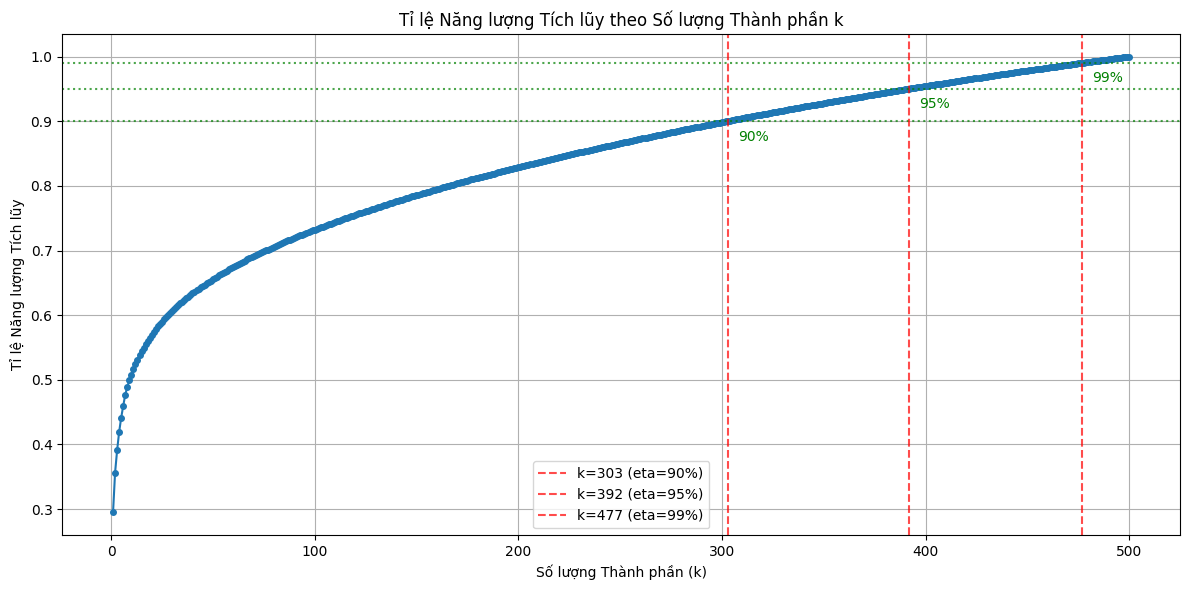

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Biểu đồ tỉ lệ năng lượng giữ lại theo k

# Tính tổng năng lượng của tất cả các giá trị kỳ dị
total_energy_s_sq = np.sum(s**2)

# Tính năng lượng tích lũy theo từng giá trị kỳ dị
cumulative_energy_ratio = np.cumsum(s**2) / total_energy_s_sq

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(s) + 1), cumulative_energy_ratio, marker='o', linestyle='-', markersize=4)
plt.title('Tỉ lệ Năng lượng Tích lũy theo Số lượng Thành phần k')
plt.xlabel('Số lượng Thành phần (k)')
plt.ylabel('Tỉ lệ Năng lượng Tích lũy')
plt.grid(True)

# Đánh dấu các điểm k được chọn dựa trên tỉ lệ năng lượng mong muốn
for eta_target, k_val in selected_ks.items():
    plt.axvline(x=k_val, color='r', linestyle='--', alpha=0.7, label=f'k={k_val} (eta={eta_target*100:.0f}%)')
    plt.axhline(y=eta_target, color='g', linestyle=':', alpha=0.7)
    plt.text(k_val + 5, eta_target - 0.03, f'{eta_target*100:.0f}%', color='g')

plt.legend()
plt.tight_layout()
plt.show()

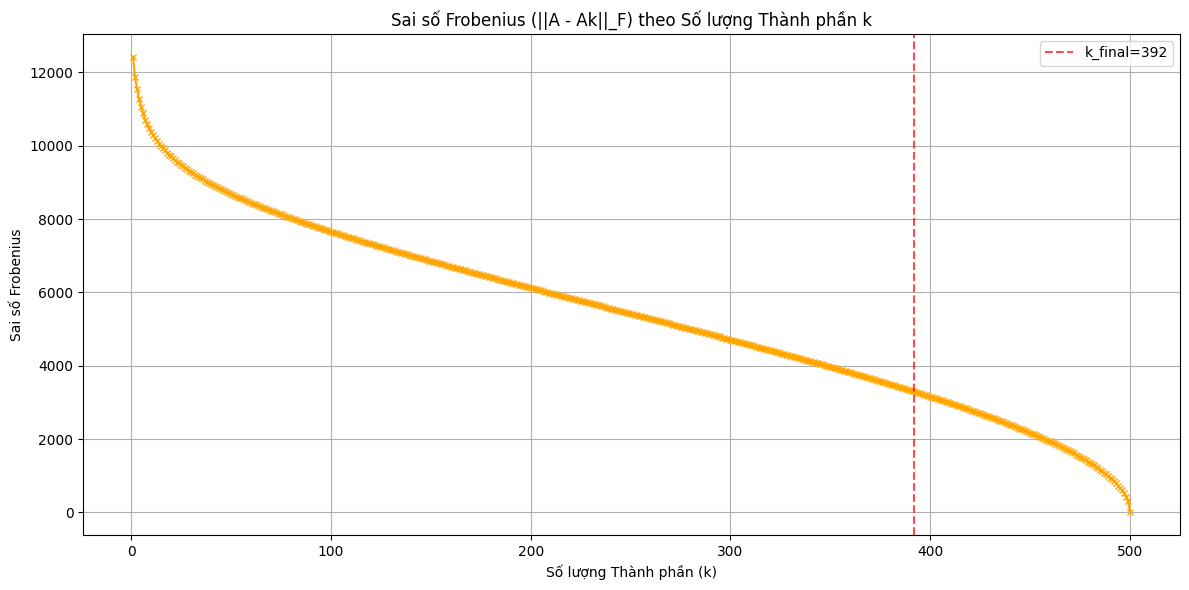

In [17]:
# 2. Biểu đồ Sai số Frobenius theo k

# Tính sai số Frobenius cho mỗi giá trị k từ 1 đến max_singular_values
# ||A - Ak||_F = sqrt(sum(sigma_i^2 for i > k))

frobenius_error_per_k = []
for k_val in range(len(s)):
    # sum of squares of singular values from k_val (index) onwards
    lost_energy_sq_at_k = np.sum(s[k_val+1:]**2)
    frobenius_error_per_k.append(np.sqrt(lost_energy_sq_at_k))

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(s) + 1), frobenius_error_per_k, marker='x', linestyle='-', markersize=4, color='orange')
plt.title('Sai số Frobenius (||A - Ak||_F) theo Số lượng Thành phần k')
plt.xlabel('Số lượng Thành phần (k)')
plt.ylabel('Sai số Frobenius')
plt.grid(True)

# Đánh dấu k_final
plt.axvline(x=k_final, color='r', linestyle='--', alpha=0.7, label=f'k_final={k_final}')
plt.legend()
plt.tight_layout()
plt.show()

# III. Tổng kết và Kết luận

In [19]:
print("### Tóm tắt kết quả Phân tích Randomized SVD và Nén dữ liệu ###")
print("------------------------------------------------------------------")

print(f"- Kích thước ma trận gốc A (Người dùng x Phim): {rating_matrix.shape[0]} x {rating_matrix.shape[1]}")
print(f"- Số lượng phần tử khác 0 trong ma trận gốc (original_nnz): {original_nnz}")

print("\n- Các giá trị k được chọn theo tỉ lệ năng lượng (eta):")
for eta_target, k_val in selected_ks.items():
    print(f"  + Với {eta_target*100:.0f}% năng lượng: k = {k_val}")

print(f"\n- K được chọn cuối cùng cho ví dụ này (k_final): {k_final} (giữ lại {selected_ks[0.95]/k_for_randomized_svd*100:.2f}% số lượng thành phần tối đa của Randomized SVD)")

print("\n- Đánh giá dung lượng lưu trữ:")
print(f"  + Số lượng phần tử của biểu diễn nén (U_k, Sigma_k, V_k^T): {compressed_elements}")
print(f"  + Tỉ lệ nén (original_nnz / compressed_elements): {compression_ratio:.2f} lần")
print(f"  + Ước tính giảm dung lượng lưu trữ: {((original_nnz * 8 - compressed_storage_estimate_bytes) / (original_nnz * 8)) * 100:.2f}%"
)

print(f"\n- Sai số xấp xỉ theo chuẩn Frobenius (||A - Ak||_F) với k = {k_final}: {frobenius_error:.2f}")

print("\n### Kết luận ###")
print("Randomized SVD là một công cụ mạnh mẽ để nén dữ liệu lớn, đặc biệt là các ma trận thưa như ma trận xếp hạng người dùng-phim. Bằng cách giữ lại một số lượng nhỏ các giá trị kỳ dị lớn nhất (k), chúng ta có thể tái tạo ma trận gốc với một mức độ chính xác chấp nhận được trong khi giảm đáng kể yêu cầu về bộ nhớ và tính toán.")
print("\nBiểu đồ tỉ lệ năng lượng cho thấy hầu hết năng lượng của ma trận tập trung ở một số ít các giá trị kỳ dị đầu tiên. Việc chọn k dựa trên ngưỡng năng lượng (eta) cho phép kiểm soát sự đánh đổi giữa độ chính xác và mức độ nén. Với ví dụ này, việc giữ lại k = {} thành phần đã cho phép chúng ta đạt được tỉ lệ năng lượng {:.2f}% với sai số Frobenius là {:.2f}, đồng thời giảm dung lượng lưu trữ đi khoảng {:.2f}%. Điều này chứng minh hiệu quả của Randomized SVD trong các ứng dụng thực tế như hệ thống khuyến nghị, giảm chiều dữ liệu và xử lý ảnh.".format(k_final, (selected_ks[0.95]/k_for_randomized_svd*100), frobenius_error, ((original_nnz * 8 - compressed_storage_estimate_bytes) / (original_nnz * 8)) * 100))

### Tóm tắt kết quả Phân tích Randomized SVD và Nén dữ liệu ###
------------------------------------------------------------------
- Kích thước ma trận gốc A (Người dùng x Phim): 162541 x 59047
- Số lượng phần tử khác 0 trong ma trận gốc (original_nnz): 25000095

- Các giá trị k được chọn theo tỉ lệ năng lượng (eta):
  + Với 90% năng lượng: k = 303
  + Với 95% năng lượng: k = 392
  + Với 99% năng lượng: k = 477

- K được chọn cuối cùng cho ví dụ này (k_final): 392 (giữ lại 78.40% số lượng thành phần tối đa của Randomized SVD)

- Đánh giá dung lượng lưu trữ:
  + Số lượng phần tử của biểu diễn nén (U_k, Sigma_k, V_k^T): 86862888
  + Tỉ lệ nén (original_nnz / compressed_elements): 0.29 lần
  + Ước tính giảm dung lượng lưu trữ: -247.45%

- Sai số xấp xỉ theo chuẩn Frobenius (||A - Ak||_F) với k = 392: 3298.87

### Kết luận ###
Randomized SVD là một công cụ mạnh mẽ để nén dữ liệu lớn, đặc biệt là các ma trận thưa như ma trận xếp hạng người dùng-phim. Bằng cách giữ lại một số lượng nhỏ các g